In [180]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import sobel, gaussian_filter
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks
from scipy.optimize import curve_fit


from chars import greek, phys


In [181]:
cwd = Path(os.getcwd())

# results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'feature testing' / 't=26.0nm Λ=500nm FF=0.76 N=75' / 'data'

results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'WS₂, SiO₂, Si' / 't=18.0nm Λ=500nm FF=0.84 N=75' / 'data'


files = sorted(os.listdir(results_dir))
file_R = results_dir / files[4]
file_R_sub = results_dir / files[5]
print(file_R)


C:\Users\whamp\PycharmProjects\research_project\WS2_Grating_Eamonn\Results\WS₂, SiO₂, Si\t=18.0nm Λ=500nm FF=0.84 N=75\data\WS₂, SiO₂, Si - t=18.0nm Λ=500nm FF=0.84_R_sub.csv


In [182]:
R = pd.read_csv(file_R, index_col=0)
Rsub = pd.read_csv(file_R_sub, index_col=0)

signalR = (R - Rsub) / Rsub
signalR = (signalR - np.min(signalR)) / (np.max(signalR) - np.min(signalR))

signalR.describe()

,-5.000000000000000000e+00,-4.864864864864864913e+00,-4.729729729729729826e+00,-4.594594594594594739e+00,-4.459459459459459651e+00,-4.324324324324324564e+00,-4.189189189189189477e+00,-4.054054054054054390e+00,-3.918918918918918859e+00,-3.783783783783783772e+00,...,3.783783783783784216e+00,3.918918918918919303e+00,4.054054054054054390e+00,4.189189189189189477e+00,4.324324324324324564e+00,4.459459459459459651e+00,4.594594594594594739e+00,4.729729729729729826e+00,4.864864864864864913e+00,5.000000000000000000e+00
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,...,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,0.327463,0.309657,0.293935,0.279307,0.264159,0.250787,0.240967,0.232193,0.221710,0.214354,...,0.214354,0.221710,0.232193,0.240967,0.250787,0.264159,0.279307,0.293935,0.309657,0.327463
std,0.158482,0.156259,0.154541,0.153006,0.150349,0.148387,0.146941,0.144541,0.140126,0.139107,...,0.139107,0.140126,0.144541,0.146941,0.148387,0.150349,0.153006,0.154541,0.156259,0.158482
min,0.099518,0.093637,0.088546,0.083038,0.078181,0.073953,0.069405,0.065353,0.061655,0.057822,...,0.057822,0.061655,0.065353,0.069405,0.073953,0.078181,0.083038,0.088546,0.093637,0.099518
25%,0.226243,0.211702,0.187672,0.178312,0.161298,0.145269,0.142943,0.144091,0.144486,0.132411,...,0.132411,0.144486,0.144091,0.142943,0.145269,0.161298,0.178312,0.187672,0.211702,0.226243
50%,0.325668,0.302878,0.289196,0.269220,0.250970,0.234261,0.218936,0.204859,0.193428,0.186420,...,0.186420,0.193428,0.204859,0.218936,0.234261,0.250970,0.269220,0.289196,0.302878,0.325668
75%,0.377170,0.352234,0.330289,0.309683,0.290878,0.273597,0.258003,0.243282,0.229602,0.216839,...,0.216839,0.229602,0.243282,0.258003,0.273597,0.290878,0.309683,0.330289,0.352234,0.377170
max,1.000000,0.977863,0.956082,0.934698,0.913755,0.893296,0.873370,0.854029,0.835334,0.817351,...,0.817351,0.835334,0.854029,0.873370,0.893296,0.913755,0.934698,0.956082,0.977863,1.000000


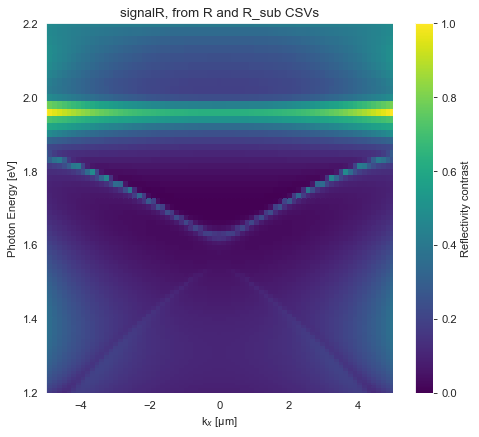

In [183]:
N=75
lbda_min = 1240 / 2.2 # y limits
lbda_max = 1240 / 1.2
lbda = np.linspace(lbda_min/1000,lbda_max/1000,N)
N_k=N
# k_scan=np.linspace(-6.7,6.7,N_k) #mu-1
kmax=5
k_scan=np.linspace(-kmax,kmax,N_k) #mu-1
ky=0.000
title_name = 'signalR, from R and R_sub CSVs'

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,signalR,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title=title_name)
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()

(75, 75)


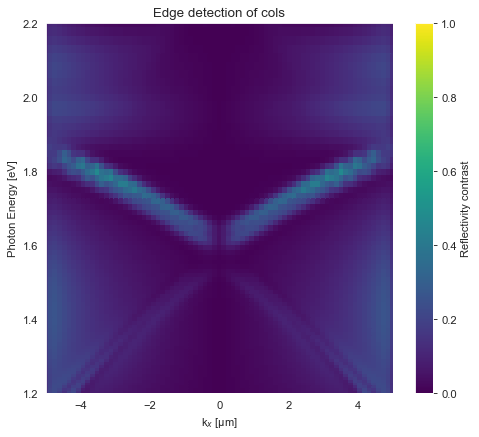

In [184]:
cwd=Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)


data_array = np.asarray(signalR)
sobel_y = sobel(data_array, axis=1) # Apply the Sobel operator y direction

edge_magnitude = np.abs(sobel_y)

# Normalize edge magnitude for better visualization
edge_magnitude_normalized = edge_magnitude / np.max(edge_magnitude)

# Apply Gaussian blur to smooth the edges (adjust sigma as needed for desired blur amount)
sigma = 0.8
edge_magnitude_blurred = gaussian_filter(edge_magnitude_normalized, sigma=sigma)


print(edge_magnitude.shape)

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,edge_magnitude_blurred,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title='Edge detection of cols')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()
plt.savefig(testpath / 'edgedetect.png', dpi=150)


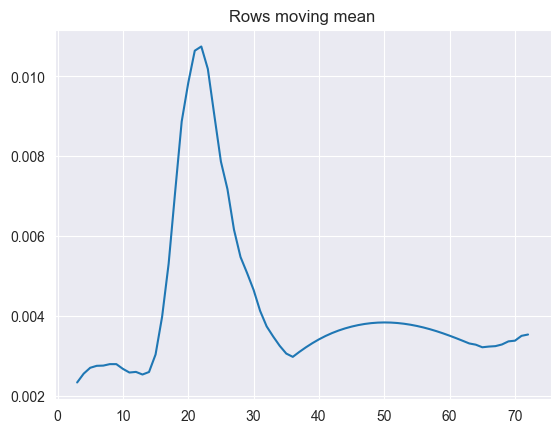

In [185]:

# find the coords of above and below the top mode, identify the gap
line_y_max = [np.max(row)*np.mean(row)/np.sum(row) for row in edge_magnitude_normalized]

# apply 3 point moving average to line_y_max

pd_line_y_max = pd.Series(line_y_max)
# pd_line_y_max.plot(title='Max val of rows')

# Apply a 3-point moving average to smooth the data
pd_line_y_max_smoothed = pd_line_y_max.rolling(window=6, center=True).mean()
pd_line_y_max_smoothed.plot(title='Rows moving mean')

plt.savefig(testpath / 'lineprofile.png', dpi=150)


Peak at 12 - before=11, after=13, diff 1.5412197591146808e-05
Peak at 22 - before=13, after=36, diff 0.007776926488022175
Peak at 50 - before=36, after=65, diff 0.0006219510894792742
Found peak at idx 22


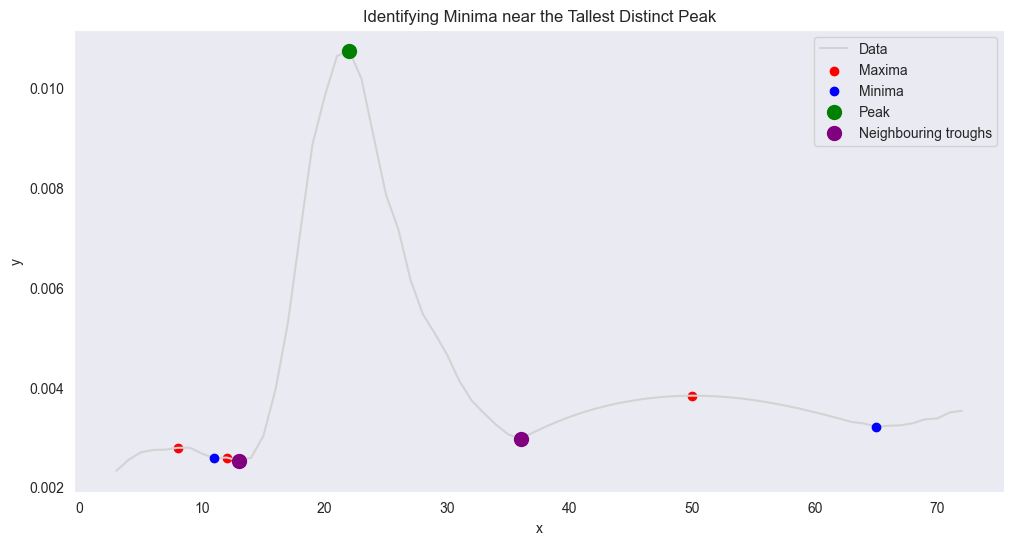

In [186]:

# Use the Series index as x values
y = pd_line_y_max_smoothed
x = pd_line_y_max_smoothed.index

peaks, _ = find_peaks(y)
troughs, _ = find_peaks(-y)  # Invert y to find minima

# peaks_df = pd.Series(peaks)
# troughs_df = pd.Series(troughs)
# pt_df = pd.DataFrame({'peaks':peaks_df, 'troughs':troughs_df})
# print(pt_df)

minima_indices = troughs
min_peak_trough_diff = 0.6

max_peak = None # [loc, comparable diff]
min_troughs = None # [loc1, loc2]

for _,peak in enumerate(peaks):
    before_trough = troughs[troughs < peak].max() if (troughs < peak).any() else None
    after_trough = troughs[troughs > peak].min() if (troughs > peak).any() else None
    
    if None in [before_trough, after_trough]:
        continue
    before_trough = int(before_trough)
    after_trough = int(after_trough)
    
    diff1, diff2 = y[peak] - y[before_trough], y[peak] - y[after_trough]
    diff_min = np.min([diff1, diff2]) # find min proximity in y to trough
    
    if max_peak == None or max_peak[1] < diff_min:
        max_peak = [peak,diff_min]
        min_troughs = [before_trough, after_trough]
    
    print(f"Peak at {peak} - before={before_trough}, after={after_trough}, diff {diff_min}")

print(f"Found peak at idx {max_peak[0]}")
    


# Step 5: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Data', color='lightgray')
plt.scatter(x[peaks], y[peaks], color='red', label='Maxima')
plt.scatter(x[minima_indices], y[minima_indices], color='blue', label='Minima', zorder=5)
plt.scatter(x[max_peak[0]], y[max_peak[0]], color='green', label='Peak', s=100, zorder=10)
plt.scatter([x[min_troughs[0]], x[min_troughs[1]]], [y[min_troughs[0]], y[min_troughs[1]]], color='purple', label='Neighbouring troughs', s=100, zorder=10)
plt.title('Identifying Minima near the Tallest Distinct Peak')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.savefig(testpath / 'peaks.png', dpi=150)
plt.show()

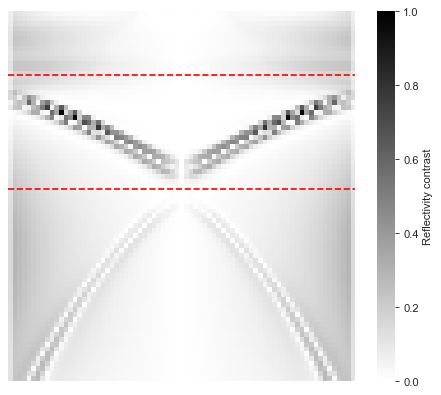

In [187]:
# Create a new figure for the heatmap
plt.figure(figsize=(7, 6), dpi=80)

# Use seaborn to create a heatmap
sns.heatmap(edge_magnitude_normalized, cmap='binary', cbar_kws={'label': 'Reflectivity contrast'}, 
            xticklabels=False, yticklabels=False)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

plt.minorticks_on()

In [188]:
# # Sample data generation (replace with your actual data)
# # edge_magnitude_normalized = np.random.rand(100, 50)  # Example heatmap data
# # min_troughs = [20, 80]  # Example trough indices
# 
# # Create a new figure for the heatmap
# plt.figure(figsize=(7, 6), dpi=80)
# 
# # Create the heatmap
# sns.heatmap(edge_magnitude_normalized, cmap='binary',
#             xticklabels=False, yticklabels=False)
# 
# # Add horizontal lines at the minimum troughs
# plt.axhline(y=min_troughs[0], color='r', linestyle='--', label='Mode max/min')
# plt.axhline(y=min_troughs[1], color='r', linestyle='--')
# 
# # Extract the region of interest between the minimum troughs
# y_min = min_troughs[0]
# y_max = min_troughs[1]
# 
# # Extract data between the specified rows
# data_region = edge_magnitude_normalized[y_min:y_max, :]  # Get data between min_troughs
# 
# # Define a threshold for high values; you can adjust this value as necessary
# # Extract the x-coordinates
# x_indices = np.arange(data_region.shape[1])  # x-coordinates (columns)
# 
# # Calculate the weighted average of y-positions for each x
# y_positions = []
# 
# for x in x_indices:
#     column = data_region[:, x]
#     
#     # Calculate the 75th percentile (for top 25% of values)
#     threshold = np.percentile(column, 85)
#     
#     # Consider only values above the 75th percentile
#     top_quarter = column[column >= threshold]
#     y_indices = np.where(column >= threshold)[0]
#     
#     if len(top_quarter) > 0:
#         # Calculate weighted average for the top quarter
#         weighted_avg = np.sum(top_quarter * y_indices) / np.sum(top_quarter)
#         y_positions.append(weighted_avg + y_min)  # Shift by y_min
#     else:
#         # If no values above threshold, use the maximum value's position
#         y_positions.append(np.argmax(column) + y_min)
# 
# # Fit a spline to the weighted average positions
# spline_fit = UnivariateSpline(x_indices, y_positions, s=10)  # s=0.5 for some smoothing
# x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
# y_smooth = spline_fit(x_smooth)
# 
# spline_derivative = spline_fit.derivative()
# gradient = spline_derivative(x_smooth)
# 
# # plt.plot(x_smooth, gradient, color='green', linewidth=2, label='Gradient')
# 
# lhs_inflection = x_smooth[np.argmax(gradient)]
# rhs_inflection = x_smooth[np.argmin(gradient)]
# # print(f"Gradient: {lhs_inflection}, {rhs_inflection}")
# 
# kmax = 5
# 
# krange = 2*kmax
# scale = krange/np.max(x_smooth)
# k_lhs, k_rhs= scale*lhs_inflection-kmax, scale*rhs_inflection-kmax
# print(f"K_x inflection at {k_lhs}, {k_rhs}")
# 
# plt.plot(x_smooth, y_smooth, color='blue', linewidth=2, label='Spline Fit')
# 
# # Add horizontal lines at the minimum troughs
# plt.axvline(x=lhs_inflection, color='g', linestyle='--', label='Inflection')
# plt.axvline(x=rhs_inflection, color='g', linestyle='--')
# 
# 
# 
# 
# # Adding a legend and displaying the plot
# plt.legend()
# plt.xticks()
# plt.minorticks_on()
# plt.title('Points of inflection for upper mode')
# 
# plt.savefig(testpath / 'inflections.png', dpi=150)
# plt.show()


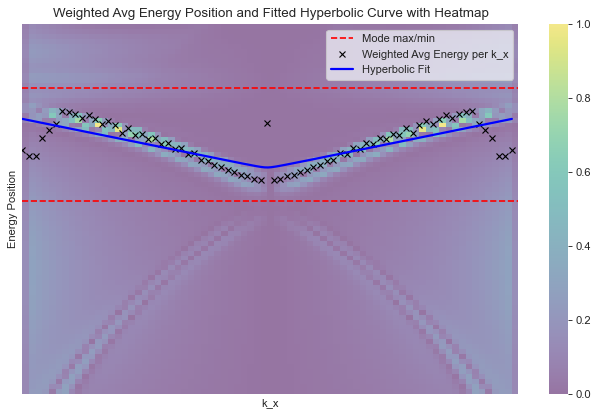

Fitted parameters:
h = 29.3705, a = -0.2487, b = 0.9112, k = 37.0000


In [189]:

# Define the hyperbolic model function for curve fitting
def hyperbolic_model(x, h, a, b, k):
    return h + a * np.sqrt(1 + (x - k)**2 / b**2)

# Directory setup
cwd = Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[0], min_troughs[1]
data_region = edge_magnitude_normalized[y_min:y_max, :]  # Get data between min_troughs
x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))  # y-axis indices (energies)

    # Find the threshold for the top 25% quantile
    quantile_threshold = np.percentile(column, 80)

    # Filter values to only those above the 75th percentile
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]  # Corresponding y indices

    # Calculate the weighted average for the filtered values
    if np.sum(filtered_column) > 0:  # Avoid division by zero if the filtered column is empty
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)  # Adjust by y_min to reflect the original position
    else:
        # If no values exceed the threshold, use a fallback value
        y_positions.append((y_max + y_min) / 2)

# Convert to arrays for curve fitting
x_data = np.array(x_indices)
y_data = np.array(y_positions)

# Perform curve fitting (using hyperbolic fit)
initial_guess = [np.mean(y_data), 1, 1, np.mean(x_data)]
popt, pcov = curve_fit(hyperbolic_model, x_data, y_data, p0=initial_guess)

# Generate smooth x-values for plotting the fitted curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_fit = hyperbolic_model(x_smooth, *popt)

# Overlay the weighted average data and the fitted hyperbolic curve on the heatmap
plt.plot(x_data, y_data, 'x', color='black', markersize=6, label='Weighted Avg Energy per k_x')
plt.plot(x_smooth, y_fit, color='blue', linewidth=2, label='Hyperbolic Fit')

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('Energy Position')
plt.legend()
plt.xticks()
plt.minorticks_on()
plt.title('Weighted Avg Energy Position and Fitted Hyperbolic Curve with Heatmap')
plt.savefig(testpath / 'hyperbolic_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
h, a, b, k = popt
print(f"Fitted parameters:\nh = {h:.4f}, a = {a:.4f}, b = {b:.4f}, k = {k:.4f}")


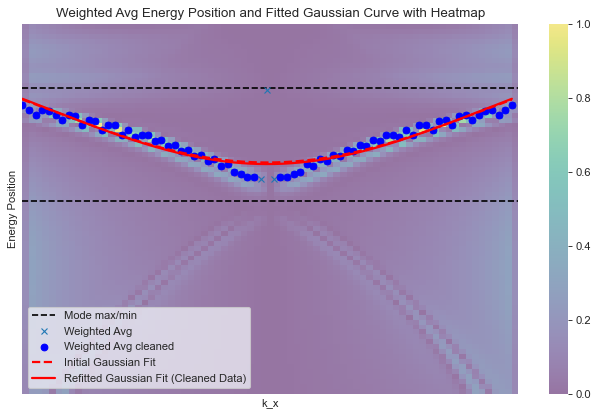

Fitted parameters (initial Gaussian):
A = 945.4997, mu = 37.0000, sigma = 33.6373
Fitted parameters (cleaned Gaussian):
A = 939.2051, mu = 37.0000, sigma = 33.0346


In [227]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define the Gaussian model function for curve fitting
def gaussian_model(x, A, mu, sigma):
    return (A/(sigma)) * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Directory setup
cwd = Path().cwd()
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='black', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='black', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[0], min_troughs[1]
data_region = edge_magnitude_normalized[y_min:y_max, :]
x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))

    quantile_threshold = np.percentile(column, 95)
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]

    if np.sum(filtered_column) > 0:
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)
    else:
        y_positions.append((y_max + y_min) / 2)

x_data = np.array(x_indices)
y_data = np.array(y_positions)

# Initial guess for Gaussian fit parameters
initial_guess = [np.max(y_data), np.mean(x_data), 100]

# Perform Gaussian curve fitting
popt, pcov = curve_fit(gaussian_model, x_data, y_data, p0=initial_guess)

# Generate smooth x-values for plotting the fitted Gaussian curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_fit = gaussian_model(x_smooth, *popt)

# Calculate residuals and identify outliers
residuals = y_data - gaussian_model(x_data, *popt)
threshold = 1.5 * np.std(residuals)
outlier_indices = np.abs(residuals) > threshold
x_data_cleaned = x_data[~outlier_indices]
y_data_cleaned = y_data[~outlier_indices]

# Refit the Gaussian model to the cleaned data
popt_cleaned, pcov_cleaned = curve_fit(gaussian_model, x_data_cleaned, y_data_cleaned, p0=initial_guess)
y_fit_cleaned = gaussian_model(x_smooth, *popt_cleaned)

# Overlay the data and the fitted Gaussian curve on the heatmap
plt.plot(x_data, y_data, 'x', markersize=6, label='Weighted Avg')
plt.plot(x_data_cleaned, y_data_cleaned, 'bo', markersize=6, label='Weighted Avg cleaned')
plt.plot(x_smooth, y_fit, 'r--', linewidth=2, label='Initial Gaussian Fit')
plt.plot(x_smooth, y_fit_cleaned, 'r-', linewidth=2, label='Refitted Gaussian Fit (Cleaned Data)')

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('Energy Position')
plt.legend()
plt.minorticks_on()
plt.title('Weighted Avg Energy Position and Fitted Gaussian Curve with Heatmap')
plt.savefig(testpath / 'gaussian_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
A, mu, sigma = popt
print(f"Fitted parameters (initial Gaussian):\nA = {A:.4f}, mu = {mu:.4f}, sigma = {sigma:.4f}")

A_cleaned, mu_cleaned, sigma_cleaned = popt_cleaned
print(f"Fitted parameters (cleaned Gaussian):\nA = {A_cleaned:.4f}, mu = {mu_cleaned:.4f}, sigma = {sigma_cleaned:.4f}")


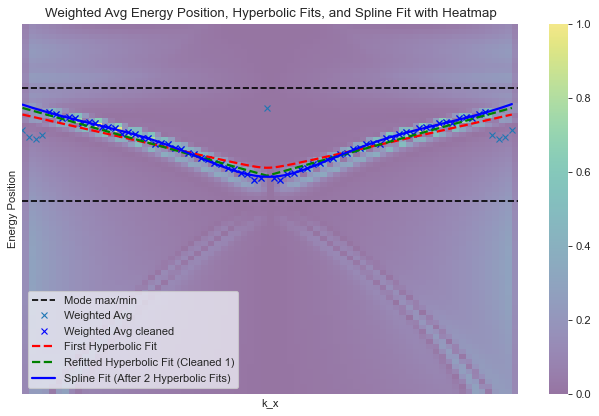

Fitted parameters (first hyperbolic):
h = 29.7475, a = -0.5656, b = 1.8428, k = 37.0000
Fitted parameters (second hyperbolic):
h = 30.7948, a = -0.0002, b = 0.0006, k = 37.0000


In [191]:

# Define the hyperbolic model function for curve fitting
def hyperbolic_model(x, h, a, b, k):
    return h + a * np.sqrt(1 + (x - k)**2 / b**2)

# Directory setup
cwd = Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='black', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='black', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[0], min_troughs[1]
data_region = edge_magnitude_normalized[y_min:y_max, :]  # Get data between min_troughs
x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))  # y-axis indices (energies)

    # Find the threshold for the top 25% quantile
    quantile_threshold = np.percentile(column, 90)

    # Filter values to only those above the 75th percentile
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]  # Corresponding y indices

    # Calculate the weighted average for the filtered values
    if np.sum(filtered_column) > 0:  # Avoid division by zero if the filtered column is empty
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)  # Adjust by y_min to reflect the original position
    else:
        # If no values exceed the threshold, use a fallback value
        y_positions.append((y_max + y_min) / 2)

# Convert to arrays for curve fitting
x_data = np.array(x_indices)
y_data = np.array(y_positions)

# Function for fitting and removing outliers
def fit_hyperbolic_and_remove_outliers(x_data, y_data, initial_guess):
    # Perform hyperbolic curve fitting
    popt, pcov = curve_fit(hyperbolic_model, x_data, y_data, p0=initial_guess)

    # Calculate residuals
    residuals = y_data - hyperbolic_model(x_data, *popt)

    # Identify outliers
    threshold = 1.5 * np.std(residuals)
    outlier_indices = np.abs(residuals) > threshold

    # Remove outliers
    x_data_cleaned = x_data[~outlier_indices]
    y_data_cleaned = y_data[~outlier_indices]

    return popt, x_data_cleaned, y_data_cleaned

# Initial guess for the hyperbolic fit
initial_guess = [np.mean(y_data), 1, 1, np.mean(x_data)]

# First hyperbolic fit and outlier removal
popt_1, x_data_cleaned_1, y_data_cleaned_1 = fit_hyperbolic_and_remove_outliers(x_data, y_data, initial_guess)

# Second hyperbolic fit and outlier removal
popt_2, x_data_cleaned_2, y_data_cleaned_2 = fit_hyperbolic_and_remove_outliers(x_data_cleaned_1, y_data_cleaned_1, initial_guess)

# Generate smooth x-values for the new fitted curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)

# Fit a spline to the cleaned data after two hyperbolic fits
spline_smoothing_factor = 6  # Adjust smoothing factor as needed
spline_fit = UnivariateSpline(x_data_cleaned_2, y_data_cleaned_2, s=spline_smoothing_factor)
y_fit_spline = spline_fit(x_smooth)

# Overlay the weighted average data and the fitted curves on the heatmap
plt.plot(x_data, y_data, 'x', markersize=6, label='Weighted Avg')
plt.plot(x_data_cleaned_2, y_data_cleaned_2, 'bx', markersize=6, label='Weighted Avg cleaned')
plt.plot(x_smooth, hyperbolic_model(x_smooth, *popt_1), 'r--', linewidth=2, label='First Hyperbolic Fit')
plt.plot(x_smooth, hyperbolic_model(x_smooth, *popt_2), 'g--', linewidth=2, label='Refitted Hyperbolic Fit (Cleaned 1)')
plt.plot(x_smooth, y_fit_spline, 'b-', linewidth=2, label='Spline Fit (After 2 Hyperbolic Fits)')

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('Energy Position')
plt.legend()
plt.xticks()
plt.minorticks_on()
plt.title('Weighted Avg Energy Position, Hyperbolic Fits, and Spline Fit with Heatmap')
plt.savefig(testpath / 'hyperbolic_and_spline_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
h_1, a_1, b_1, k_1 = popt_1
print(f"Fitted parameters (first hyperbolic):\nh = {h_1:.4f}, a = {a_1:.4f}, b = {b_1:.4f}, k = {k_1:.4f}")

# Print fitted parameters for cleaned data after second fit
h_2, a_2, b_2, k_2 = popt_2
print(f"Fitted parameters (second hyperbolic):\nh = {h_2:.4f}, a = {a_2:.4f}, b = {b_2:.4f}, k = {k_2:.4f}")


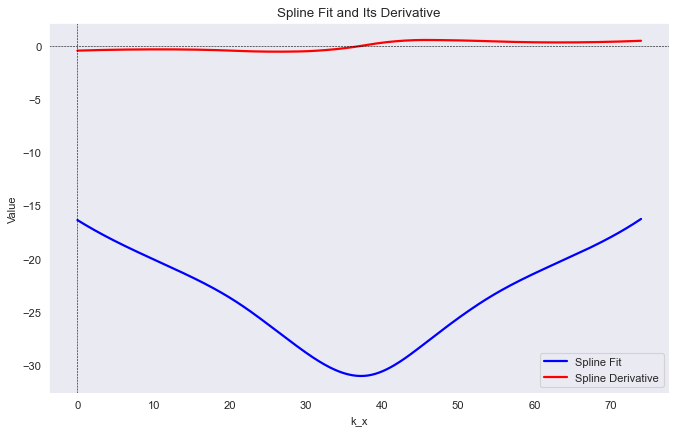

In [192]:


# Generate smooth x-values for plotting the spline and its derivative
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)

# Calculate the spline values and its derivative
spline_fit_values = -spline_fit(x_smooth)
spline_derivative = -spline_fit.derivative()(x_smooth)

# Create a new figure for plotting the spline and its derivative
plt.figure(figsize=(10, 6), dpi=80)

# Plot the spline fit
plt.plot(x_smooth, spline_fit_values, 'b-', label='Spline Fit', linewidth=2)

# Plot the derivative of the spline
plt.plot(x_smooth, spline_derivative, 'r-', label='Spline Derivative', linewidth=2)

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('Value')
plt.title('Spline Fit and Its Derivative')
plt.axhline(0, color='black', lw=0.5, linestyle='--')  # Add a horizontal line at y=0 for reference
plt.axvline(0, color='black', lw=0.5, linestyle='--')  # Add a vertical line at x=0 for reference
plt.legend()
plt.grid()
plt.show()


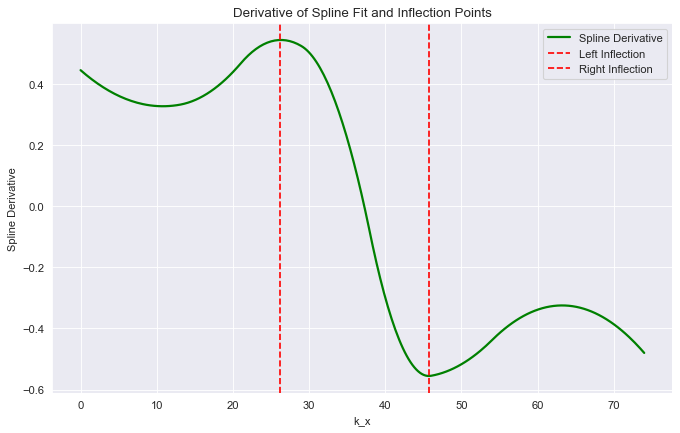

Inflection points at k_x = -1.50 and k_x = 1.10
Average = 1.30
27.72408026755853 47.27591973244147


In [206]:
# Calculate the derivative of the fitted spline
spline_derivative = spline_fit.derivative()  # First derivative of the spline
gradient = spline_derivative(x_smooth)       # Evaluate derivative at x_smooth points

# Plot the gradient (derivative of the spline)
plt.figure(figsize=(10, 6), dpi=80)
plt.plot(x_smooth, gradient, color='green', linewidth=2, label='Spline Derivative')

# Find the inflection points by locating maxima and minima of the gradient
lhs_inflection_index = np.argmax(gradient)  # Index of the maximum derivative
rhs_inflection_index = np.argmin(gradient)  # Index of the minimum derivative

# Map indices back to x values to find inflection points
lhs_inflection = x_smooth[lhs_inflection_index]
rhs_inflection = x_smooth[rhs_inflection_index]

# Add vertical lines at the inflection points
plt.axvline(x=lhs_inflection, color='red', linestyle='--', label='Left Inflection')
plt.axvline(x=rhs_inflection, color='red', linestyle='--', label='Right Inflection')

# Adding a legend and displaying the plot
plt.legend()
plt.xlabel('k_x')  # Label for x-axis
plt.ylabel('Spline Derivative')  # Label for y-axis
plt.title('Derivative of Spline Fit and Inflection Points')
plt.grid(True)  # Optional: add grid for better visibility
plt.savefig(testpath / 'spline_derivative_inflections.png', dpi=150)
plt.show()

k_lhs = -5 + (lhs_inflection/75)*10
k_rhs = -5 + (rhs_inflection/75)*10
k_avg = (abs(k_lhs)+abs(k_rhs))/2
# Print inflection points for reference
print(f"Inflection points at k_x = {k_lhs:.2f} and k_x = {k_rhs:.2f}")
print(f"Average = {k_avg:.2f}")

avg_inflection = ((k_avg+5)/10)*75
avg_inflection_neg = ((-k_avg+5)/10)*75
print(avg_inflection_neg, avg_inflection)


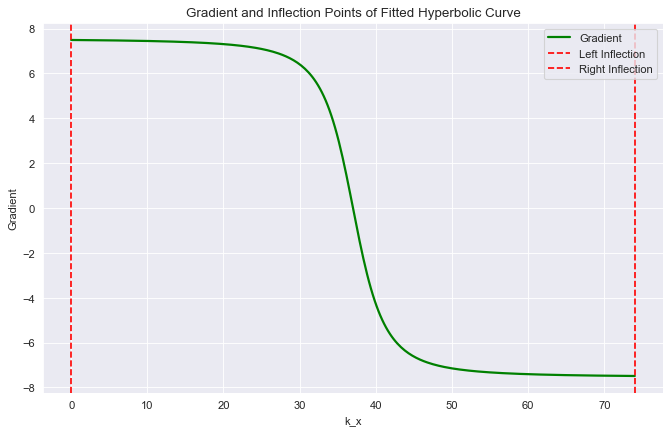

Inflection points at k_x = 0.00 and k_x = 74.00


In [223]:
# # Define the derivative function of the fitted hyperbolic model
# def hyperbolic_derivative(x, h, a, b, k):
#     # Derivative of the hyperbolic function
#     return (a * (x - k)) / np.sqrt(1 + (x - k)**2 / b**2)
# 
# # Calculate the gradient using the derivative of the fitted hyperbolic function
# gradient = hyperbolic_derivative(x_smooth, *popt)  # *popt contains h, a, b, k from the curve fit
# 
# # Plot the gradient
# plt.figure(figsize=(10, 6), dpi=80)
# plt.plot(x_smooth, gradient, color='green', linewidth=2, label='Gradient')
# 
# # Calculate inflection points based on the gradient
# lhs_inflection_index = np.argmax(gradient)  # Index of the maximum gradient
# rhs_inflection_index = np.argmin(gradient)  # Index of the minimum gradient
# 
# # Map indices back to x values to find inflection points
# lhs_inflection = x_smooth[lhs_inflection_index]
# rhs_inflection = x_smooth[rhs_inflection_index]
# 
# # Add vertical lines at the inflection points
# plt.axvline(x=lhs_inflection, color='r', linestyle='--', label='Left Inflection')
# plt.axvline(x=rhs_inflection, color='r', linestyle='--', label='Right Inflection')
# 
# # Adding a legend and displaying the plot
# plt.legend()
# plt.xlabel('k_x')  # Label for x-axis
# plt.ylabel('Gradient')  # Label for y-axis
# plt.title('Gradient and Inflection Points of Fitted Hyperbolic Curve')
# plt.grid(True)  # Optional: add grid for better visibility
# plt.savefig(testpath / 'inflections.png', dpi=150)
# plt.show()
# 
# # Print inflection points for reference
# print(f"Inflection points at k_x = {lhs_inflection:.2f} and k_x = {rhs_inflection:.2f}")


In [195]:
# spline_derivative = spline_fit.derivative()
# gradient = spline_derivative(x_smooth)
# 
# plt.plot(x_smooth, gradient, color='green', linewidth=2, label='Gradient')
# 
# # Add horizontal lines at the minimum troughs
# plt.axvline(x=lhs_inflection, color='r', linestyle='--')
# plt.axvline(x=rhs_inflection, color='r', linestyle='--')


Inflection points at x = 26.23 and x = 45.79


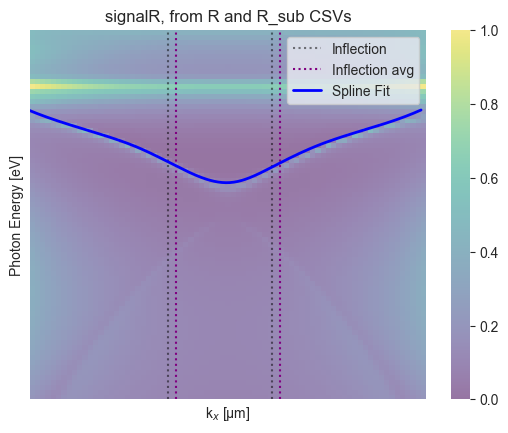

In [222]:
# fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
# pcm = axs.pcolor(k_scan,1.240/lbda,signalR,cmap='viridis',clim=(0,1))
# axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title=title_name)
# # y_eV = 1.45    # reference line at 1.45eV
# # axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
# cbar =fig.colorbar(pcm,location='right')
# cbar.set_label('Reflectivity contrast')
# # plt.minorticks_on()
sns.heatmap(signalR, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

plt.axvline(x=lhs_inflection, color='black', linestyle=':', label='Inflection', alpha=0.5)
plt.axvline(x=rhs_inflection, color='black', linestyle=':', alpha=0.5)

plt.axvline(x=avg_inflection, color='purple', linestyle=':', label='Inflection avg')
plt.axvline(x=avg_inflection_neg, color='purple', linestyle=':')

plt.plot(x_smooth, y_fit_spline, 'b-', linewidth=2, label='Spline Fit')

plt.legend()

plt.xlabel(f'k$_x$ [{greek.mu}m]')
plt.ylabel('Photon Energy [eV]')

plt.title(title_name)

final = testpath / 'final.png'
plt.savefig(final, dpi=150)

print(f"Inflection points at x = {lhs_inflection:.2f} and x = {rhs_inflection:.2f}")